In [1]:
from datetime import datetime

from e2e.e2esim import run_e2e_prediction
import matplotlib.pyplot as plt

import scienceplots

from e2e.prediction.end_to_end import Plotter

plt.style.use(['science', 'ieee', 'grid'])
plt.rcParams.update({"font.size": 12})
# plt.rcParams.update({"mathtext.default": "regular"})

%load_ext autoreload
%autoreload 2

2023-10-18 17:33:26,154 - MainThread - INFO - torch.distributed.nn.jit.instantiator - Created a temporary directory at /var/folders/4t/9f3l3jb178g28tncpwrm_fsc0000gn/T/tmp1yh991u7
2023-10-18 17:33:26,155 - MainThread - INFO - torch.distributed.nn.jit.instantiator - Writing /var/folders/4t/9f3l3jb178g28tncpwrm_fsc0000gn/T/tmp1yh991u7/_remote_module_non_scriptable.py


In [2]:
FOOTPRINT_PREDICT = False
U_THRESHOLD = 1000.0
dataset = run_e2e_prediction(None, DEVICE="cpu", FOOTPRINT_PREDICT=FOOTPRINT_PREDICT, U_THRESHOLD=U_THRESHOLD)

100%|██████████| 56/56 [00:05<00:00, 10.77it/s]
wandb:   1 of 1 files downloaded.  
/Users/magnus/miniconda3/envs/waam310/lib/python3.10/site-packages/lightning/pytorch/utilities/migration/utils.py:49: PossibleUserWarning: The loaded checkpoint was produced with Lightning v2.0.3, which is newer than your current Lightning version: v2.0.2
  rank_zero_warn(


shape-uncertainty-score@0: 4.376600742340088
footprint-uncertainty-score@0: 4.376600742340088
prediction-time@0: 0.04559898376464844


shape-uncertainty-score@1: 7.476523399353027
footprint-uncertainty-score@1: 7.476523399353027
prediction-time@1: 0.04410505294799805


shape-uncertainty-score@2: 5.417517185211182
footprint-uncertainty-score@2: 5.417517185211182
prediction-time@2: 0.04188680648803711


shape-uncertainty-score@3: 6.713388919830322
footprint-uncertainty-score@3: 6.713388919830322
prediction-time@3: 0.04438304901123047


shape-uncertainty-score@4: 5.38076114654541
footprint-uncertainty-score@4: 5.38076114654541
prediction-time@4: 0.04217720031738281

shape-uncertainty-score@5: 5.635695934295654
footprint-uncertainty-score@5: 5.635695934295654
prediction-time@5: 0.04270672798156738


shape-uncertainty-score@6: 9.437832832336426
footprint-uncertainty-score@6: 9.437832832336426
prediction-time@6: 0.04845285415649414


shape-uncertainty-score@7: 4.8431549072265625
footprint-un

In [3]:
footprint_type = "predicted" if FOOTPRINT_PREDICT else "measured"

In [ ]:
U_THRESHOLD = 1000.0
fig = Plotter.plot_e2e(
    dataset.predictions, dataset.labels, dataset.ground_truth, title="")

2023-10-18 17:33:49,334 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-18 17:33:49,642 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-18 17:33:49,645 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-18 17:33:49,647 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-18 17:33:49,649 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-18 17:33:49,651 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-18 17:33:49,653 - MainThread - INFO - matplotlib.texmanager - No LaT

In [5]:
from pathlib import Path

desktop = Path.home() / "Desktop"
fig.savefig(f"{desktop}/e2e_ex6_test_footprint:{footprint_type}.pdf", bbox_inches="tight")

2023-10-18 17:33:59,901 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-18 17:33:59,920 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-18 17:33:59,941 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-18 17:33:59,957 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-18 17:33:59,970 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-18 17:33:59,978 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-18 17:33:59,984 - MainThread - INFO - matplotlib.texmanager - No LaT

In [6]:
import numpy as np

In [7]:
outline_preds = np.array(dataset.predictions).max(axis=0)[200:901]


In [8]:
ts_zero = []
for gt in dataset.ground_truth:
    t = gt[200:901]
    offset = np.mean(t[:40])
    t = t - offset
    ts_zero.append(t)
    
ts = np.array(ts_zero)
outline_true = ts.max(axis=0)

In [9]:
from scipy.interpolate import interp1d
from scipy.spatial.distance import cdist

start = 40
end = 670

x = np.arange(0, (end-start) / 10, 0.1)

true, pred = outline_preds[start:end], outline_true[start:end]

# f_true = interp1d(x, true, kind="cubic")
# f_pred = interp1d(x, pred, kind="cubic")
# 
# x1000 = np.linspace(0, x.max(), 1000)
# 
# true, pred = f_true(x1000), f_pred(x1000)
    
xa = np.array(list(zip(x, true)))
xb = np.array(list(zip(x, pred)))

dist = cdist(xa, xb)
mins = np.min(dist, axis=1)
mod_hausdorff = np.median(mins)

print(f"Modified Hausdorff Distance: {mod_hausdorff:.4f} mm")

Modified Hausdorff Distance: 0.1119 mm


2023-10-18 17:34:09,768 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-18 17:34:09,770 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-18 17:34:09,771 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-18 17:34:09,773 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-18 17:34:09,775 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-18 17:34:09,777 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-18 17:34:09,779 - MainThread - INFO - matplotlib.texmanager - No LaT

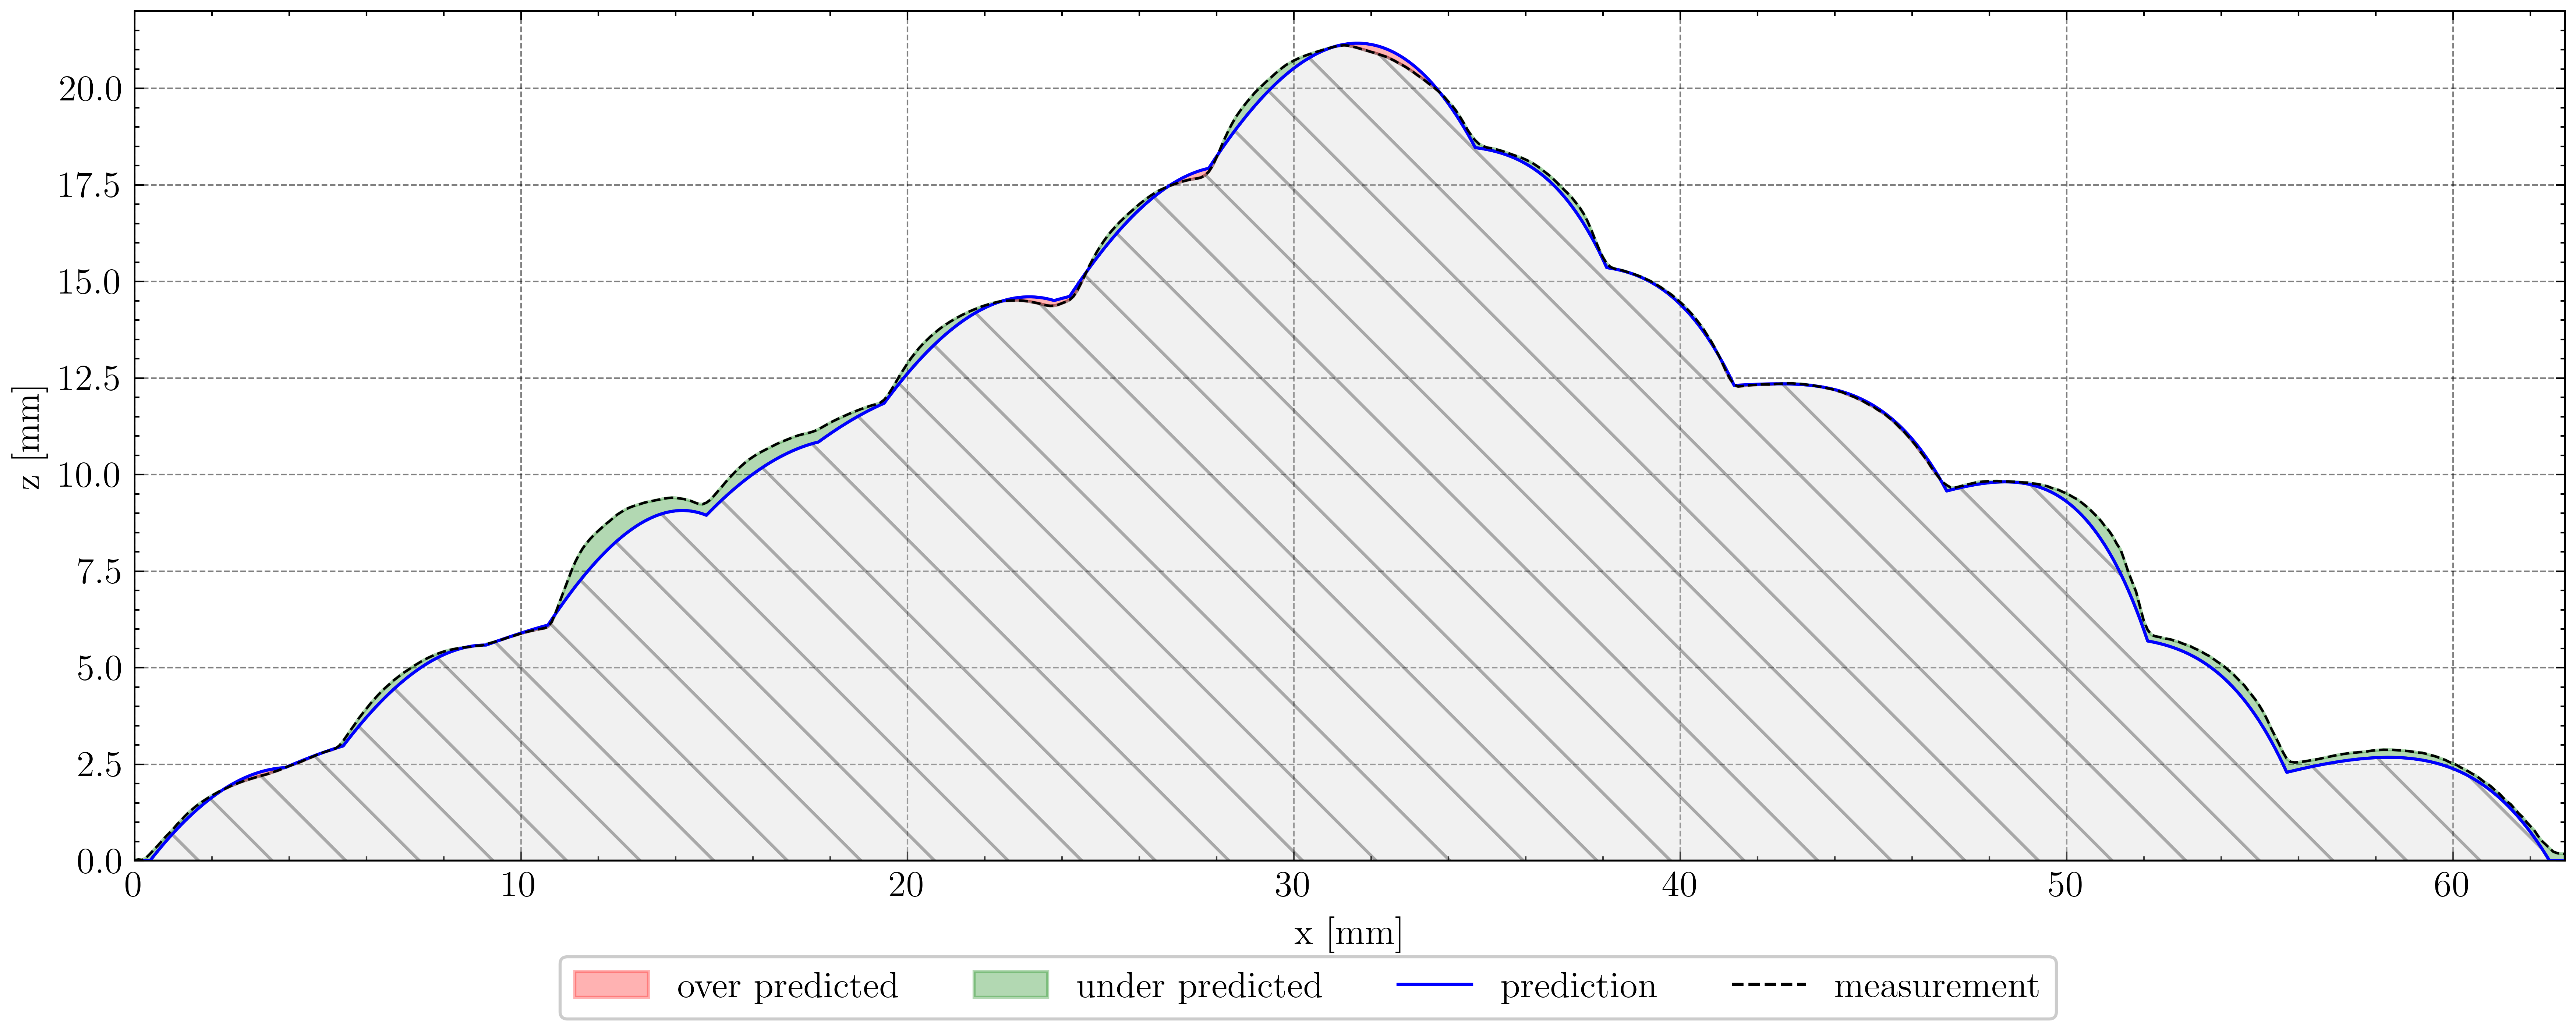

In [ ]:
fig = Plotter.plot_outline(outline_preds[start:end], outline_true[start:end])

In [11]:
fig.savefig(f"{desktop}/e2e_ex6_test_outline_footprint:{footprint_type}.pdf", bbox_inches="tight")

2023-10-18 17:34:18,462 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-18 17:34:18,464 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-18 17:34:18,466 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-18 17:34:18,468 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-18 17:34:18,469 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-18 17:34:18,471 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-10-18 17:34:18,472 - MainThread - INFO - matplotlib.texmanager - No LaT

In [12]:
area_pred = outline_preds[start:end].sum()*0.1
area_true = outline_true[start:end].sum()*0.1

print(f"Area under curve (predicted): {area_pred:.4f} mm^2")
print(f"Area under curve (true): {area_true:.4f} mm^2")

Area under curve (predicted): 633.2157 mm^2
Area under curve (true): 641.5767 mm^2


In [13]:
# integrate the area under the curve
from scipy.integrate import simps, trapz

area_pred = trapz(outline_preds[start:end], dx=0.1)
area_true = trapz(outline_true[start:end], dx=0.1)

print(f"Area under curve (predicted): {area_pred:.4f} mm^2")
print(f"Area under curve (true): {area_true:.4f} mm^2")

Area under curve (predicted): 633.2158 mm^2
Area under curve (true): 641.5674 mm^2


In [14]:
diff = outline_preds[start:end] - outline_true[start:end]

# sum where diff is positive
pos_diff = diff[diff > 0].sum()*0.1
neg_diff = diff[diff < 0].sum()*0.1

print(f"Positive difference (over prediction): {pos_diff:.4f} mm^2")
print(f"Negative difference (under prediction): {neg_diff:.4f} mm^2")

total_diff = pos_diff + neg_diff

print(f"Total difference: {total_diff:.4f} mm^2")


Positive difference (over prediction): 1.0450 mm^2
Negative difference (under prediction): -9.4060 mm^2
Total difference: -8.3610 mm^2


In [15]:
times = np.array(dataset.prediction_times)

print(f"Total time:     {times.sum()*1000:.0f} ms")
print(f"Average time:   {times.mean()*1000:.0f} ms")
print(f"Median time:    {np.median(times)*1000:.0f} ms")
print(f"Std time:       {np.std(times)*1000:.0f} ms")
print(f"Max time:       {times.max()*1000:.0f} ms")
print(f"Min time:       {times.min()*1000:.0f} ms")


Total time:     2411 ms
Average time:   43 ms
Median time:    43 ms
Std time:       2 ms
Max time:       48 ms
Min time:       40 ms


In [16]:
fp_preds = np.array([np.array([np.abs(l-112), np.abs(r-112)]) for l, r in dataset.fp_predictions])

footprints = np.array(dataset.true_footprints)
tps = np.array(dataset.torchpositions)
fp_true = [np.array([np.abs(fp.left_idx - tp), np.abs(fp.right_idx - tp)]) for fp, tp in zip(footprints, tps)]
fp_preds.shape

(0,)

In [17]:
error = (np.concatenate(np.abs(fp_preds-fp_true)) * 0.1)

ValueError: operands could not be broadcast together with shapes (0,) (56,2) 

In [18]:
error.shape

NameError: name 'error' is not defined

In [19]:
fp_true[0]

array([35, 36])

In [20]:
from scipy.stats import gaussian_kde

def plot_two_histograms(desc, labels, dataset):
    cm = 1 / 2.54
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, figsize=(18 * cm, 10 * cm), dpi=600, sharex=True, gridspec_kw={"height_ratios": [6, 1, 6, 1]},)
    
    kde_1 = gaussian_kde(dataset[0])
    x_range_1 = np.linspace(min(dataset[0]), max(dataset[0]), 500)
    ax1.plot(x_range_1, kde_1(x_range_1), color='black', label="density estimate")
    # ax1.hist(dataset[0], bins=20, density=True, histtype='step', cumulative=False, label=labels[0])
    ax2.scatter(dataset[0], [0.01]*len(dataset[0]), marker='.', alpha=0.5)
    # no y ticks on ax2
    ax2.set_yticks([])
    
    kde_2 = gaussian_kde(dataset[1])
    x_range_2 = np.linspace(min(dataset[1]), max(dataset[1]), 500)
    ax3.plot(x_range_2, kde_2(x_range_2), color='black')
    # ax2.hist(dataset[1], bins=20, density=True, histtype='step', cumulative=False, label=labels[1])
    ax4.set_yticks([])
    ax4.scatter(dataset[1], [0.01]*len(dataset[1]), marker='.', alpha=0.5, label="data points")
    
    ax1.set_position([0.1, 0.7, 0.8, 0.2])  # [left, bottom, width, height]
    ax2.set_position([0.1, 0.64, 0.8, 0.05])
    ax3.set_position([0.1, 0.35, 0.8, 0.2])
    ax4.set_position([0.1, 0.29, 0.8, 0.05])
    
    # plot mean and median in to each axis
    ax1.axvline(np.median(dataset[0]), color='red', linestyle='-.', linewidth=0.75, label=f"median")
    # ax1.axvline(np.median(dataset[0]) - np.std(dataset[0]), color='red', linestyle=':', linewidth=0.75)
    # ax1.axvline(np.median(dataset[0]) + np.std(dataset[0]), color='red', linestyle=':', linewidth=0.75)
    
    ax3.axvline(np.median(dataset[1]), color='red', linestyle='-.', linewidth=0.75)
    # ax3.axvline(np.median(dataset[1]) - np.std(dataset[1]), color='red', linestyle=':', linewidth=0.75)
    # ax3.axvline(np.median(dataset[1]) + np.std(dataset[1]), color='red', linestyle=':', linewidth=0.75)
    
    ax1.set_ylabel(desc["y-axis-1"])
    ax3.set_ylabel(desc["y-axis-2"])
    ax4.set_xlabel(desc["x-axis"])
    
    # set x label
    
    # place legend of all axis combined in one below ax4
    lines, labels = ax1.get_legend_handles_labels()
    # li3, la3 = ax3.get_legend_handles_labels()
    li4, la4 = ax4.get_legend_handles_labels()
    
    # lines.append(li3)
    lines.append(li4[0])
    # labels.append(la3)
    labels.append(la4[0])
    # add manual lable to legend
    ax4.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -1.7), ncol=3)
    # make text smaller for legend
    plt.setp(ax4.get_legend().get_texts(), fontsize='small')
    # no box around legend
    ax4.get_legend().get_frame().set_linewidth(0.0)
    return fig

In [21]:

desc = {
    "title": "",
    "x-axis": "footprint error e2e $[mm]$",
    "y-axis-1": "ResMLP",
    "y-axis-2": "Dummy",
}

labels = ["ResMLP", "ResNet"]

# poisson distribution greater than 0 and max 2
dummy = np.abs(np.random.normal(0, 1, 112))

data = [error, dummy]
# plot_two_violions(desc, labels, dataset)

fig = plot_two_histograms(desc, labels, data)

NameError: name 'error' is not defined

In [22]:
error

NameError: name 'error' is not defined

In [23]:
base = Path("outputs/mc/")
folder = Path("20231012-115741-glorious-elevator-747") 
run_name = "-".join(str(folder).split("-")[-3::])
trues = np.loadtxt(base / folder / "ys.csv", delimiter=",")
preds = np.loadtxt(base / folder/ "mean_predictions.csv", delimiter=",")
xs = np.loadtxt(base / folder / "xs.csv", delimiter=",")
ys = np.loadtxt(base / folder / "ys.csv", delimiter=",")
ids = np.loadtxt(base / folder / "ids.csv", dtype=str, delimiter=",")